# ORCA and DH-ORCA against MVP and VO at shallow crossing angles

Five conflict-resolution stacks on the same encounter distribution, over four crossing angles —
**2°, 5°, 10°, 30°** — plus a do-nothing reference:

| # | resolver | recovery | why this pairing |
| --- | --- | --- | --- |
| 1 | `MVP` | `FTR` | the package's reference potential-field stack |
| 2 | `VO` | `FTR` | the same, with a feasibility resolver |
| 3 | `ORCA` | `ORCARevert(τ)` | ORCA with its **own** revert rule |
| 4 | `DHORCA` | `ORCARevert(τ_cross)` | DH-ORCA with its **own** revert rule |
| 5 | `DHORCA` | `FTR` | the same resolver on the other three's recovery |

Rows 3 and 4 use each algorithm's native revert; both are explained below, because "ORCA's default
recovery" and "DH-ORCA's default recovery" are the two things in this notebook that are easiest to
get wrong. Row 5 exists to separate the resolver's contribution from the recovery's.

A shallow crossing is the awkward geometry for all of them: at 2° the closing speed is
`2 · gs · sin(1°) ≈ 0.36 m/s`, so the pair converges slowly, sits near CPA for a long time, and the
direction of the predicted miss — which is what MVP biases against and what VO, ORCA and DH-ORCA
pick a cone side from — is dominated by navigation error rather than by geometry. It is also
exactly the regime DH-ORCA was designed for.

**Fixed for every run.** `rpz = 50 m`, detection lookahead `60 s`, `tlos = 90 s`, GNSS self-fix
error of `10 m` / `1 m/s` (95% radial) on each aircraft, and a perfect datalink — no loss, no
latency, no stale surveillance, so every difference below is the algorithm's and not the link's.
Margin is `1.00` throughout: all of them clear to exactly `rpz`, so the comparison is between
algorithms rather than between buffers.

**Draft settings.** 2000 encounters per cell, `dt = 0.5 s`. Good enough to separate the medians and
to bound `P(LoS)`; at these rates the individual `P(LoS)` numbers carry Wilson intervals wide enough
to read carefully.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from opencdarr import (
    DHORCA,
    MVP,
    ORCA,
    VO,
    FTR,
    M600,
    MC,
    Agent,
    AircraftState,
    GnssNavigation,
    Methods,
    ORCARevert,
    StateBased,
    Sweep,
    create_conflict,
    run_experiment,
    run_fleet,
)
from opencdarr.config import (
    Config,
    ConflictConfig,
    MethodsConfig,
    ScenarioConfig,
    SimulationConfig,
)
from opencdarr.relative import relative_enu

## What ORCA's "default recovery" actually is

ORCA has no recovery layer, and that is not an omission — it is the design. Every tick it asks for
the **goal** velocity `v_pref` and returns it unchanged whenever `v_pref` already lies outside every
neighbour's truncated velocity obstacle `VO^τ`. Return-to-nominal is therefore implicit: the moment
no constraint binds, the solution *is* the nominal. Nothing has to notice that the conflict ended.

That works because ORCA re-solves from `v_pref` rather than from the current velocity, which is
exactly what `VO` cannot do here — biasing `VO` toward the nominal destabilised it (it snapped back
the moment the nominal briefly looked feasible, re-entered the conflict, and oscillated), so
`SeparationManager` calls resolvers with `preferred=None` and leaves the revert to CRR. ORCA has no
such failure mode: its half-plane is a hard constraint on the returned velocity, so asking for the
nominal cannot return something inside `VO^τ`. `opencdarr.cr.ORCA` reads the ownship's own declared
intent (`own.desired`) when the caller passes no `preferred`, which is how it gets its goal velocity
through the existing interface.

**But it still needs a recovery criterion in this framework, for a structural reason.**
`SeparationManager` keeps a pair active until a `RecoveryCriterion` retires it, and it calls the
resolver only while the *detector* is still firing; once detection stops, the aircraft **coasts on
its current velocity**. So an ORCA aircraft with `recovery=None` would never be asked the question
it answers implicitly, and would fly off its route for the rest of the run. `ORCARevert` is that
same feasibility test — *would reverting to the nominal cause an incursion within `τ`?* — moved to
the layer that can act on it. It is not a second algorithm bolted on.

Written out, `ORCARevert` is `FTR` with two deliberate differences:

| | `FTR` | `ORCARevert` |
| --- | --- | --- |
| horizon | unbounded forward CPA | `τ` — ORCA's obstacle is truncated there |
| intruder | holds current velocity, **and** reverts to its shared intent when it has one | holds current velocity only |

The second row is not a simplification for convenience: ORCA's reciprocity is an assumption about
the other aircraft's *algorithm*, not a channel it reads, so plain ORCA never consults declared
intent. Both differences make `ORCARevert` release **earlier** than `FTR` on the same geometry.

## What DH-ORCA adds, and what *its* default revert is

Dual-Horizon ORCA (Alligier, Gianazza, Durand & Olive, *JINT* 107(1), 2022) exists to fix one
specific failure of plain ORCA: the **horizon effect**. Two aircraft at similar speeds converging at
a shallow angle can be separated most cheaply by turning until their tracks are **parallel** — that
pushes the conflict just past `τ`, ORCA is satisfied, and the pair then flies side by side without
crossing. Nobody loses separation and nobody gets where they were going. Raising `τ` cures it, but
taxes every encounter including the ones that never needed a long horizon.

DH-ORCA splits that trade across two horizons:

- **`t_conflict`** (short) carries the ordinary ORCA constraint and is **always** enforced. This is
  what guarantees separation.
- **`t_cross`** (long) carries an *optional* constraint, added only when the ownship's own preferred
  course runs into the intruder within that longer horizon — the paper's `Cross(A, B)` predicate:

  $$\mathrm{Cross}(A,B) := \exists\, t \in [0, \tau_\mathrm{cross}] \;:\;
  \lVert \vec{BA} + (\vec{v}_A^{\,\mathrm{pref}} - \vec{v}_B)\,t \rVert < d$$

  When it fires, the extra constraint is built from the **untruncated** cone (`τ = +∞`, the CS-ORCA
  constraint of §5.2 — project onto the closest *side* of the full cone, never its head). That is
  what forces a crossing instead of a parallel drift. The two half-planes are **intersected**, so
  separation is never traded away for the crossing.

`Cross` is deliberately **asymmetric** — only the aircraft whose own goal crosses the other's track
pays for the extra constraint — and it reads only the ownship's intent and the intruder's *observed*
velocity, so DH-ORCA needs no intent broadcast.

**Its default revert is `ORCARevert(t_horizon=t_cross)`, and that is not a convenience choice.**
Read `Cross` again: *"would flying my nominal breach separation within `t_cross`?"* That is
**exactly** the question `ORCARevert` asks. DH-ORCA already computes that predicate every tick, so
its native revert rule is the ORCA one at the **long** horizon rather than the short one — the same
criterion, a different `τ`. There is deliberately no separate `DHORCARevert` class, because it would
be a line-for-line duplicate; `tests/test_dh_orca.py` pins the identity
`Cross(A,B) == not ORCARevert(t_cross).should_resume(...)` over a grid so the two layers cannot
drift apart. So **stack 4 is DH-ORCA with its own revert**, and it *is* different from stack 3's —
by the horizon, which is the whole point of the algorithm.

Horizons are per-scenario; the paper tunes them by grid search and its own values (`t_conflict =
52 s`, `t_cross = 372 s` against 5 NM at 230 kt) do not transfer to a 50 m zone at 20 kt. Here
`t_conflict` is set to **60 s — the same `τ` as stack 3's ORCA** — so the *only* difference between
stacks 3 and 4 is the crossing constraint and the revert horizon it implies. `t_cross = 180 s`
covers the whole encounter (`tlos = 90 s`) with room to spare. That pairing is a judgement call, not
a tuned value, and it is the main caveat on everything DH-ORCA does below.

## The declaration

One `run_experiment` call per stack, each sweeping the crossing angle. Separate calls rather than
one, because `Sweep` axes take a cross-product and the resolver and the recovery here are
**paired**, not crossed — `ORCA × FTR` is not a configuration anyone asked for. Everything else is
shared: the same `base_config`, the same seed, the same axis, so the tables differ by the stack and
nothing else.

ORCA's `t_horizon` is set to the detector's lookahead deliberately. It is the parameter with no
counterpart in MVP or VO, and pairing the two means ORCA constrains exactly the encounters the
separation manager considers conflicts — any other choice would confound "ORCA vs MVP" with "a
different definition of which conflicts exist".

`v_max = M600.v_max` gives both ORCA variants the speed channel they normally use; without it the
solution is confined to the preferred speed and they become turn-only, which is not the algorithm.

In [2]:
DPSI = [2.0, 5.0, 10.0, 30.0]  # crossing angles swept [deg]
RPZ = 50.0  # m
TAU = 60.0  # s — detection lookahead, ORCA's horizon, and DH-ORCA's t_conflict
T_CROSS = 180.0  # s — DH-ORCA's long horizon
N_ENCOUNTERS = 2000
SEED = 20260802

BASE = Config(
    seed=SEED,
    n_encounters=N_ENCOUNTERS,
    scenario=ScenarioConfig(
        aircraft_type="M600",
        speed=10.2889,  # m/s (~20 kt)
        dcpa_max=RPZ,  # miss distance ~ U(0, rpz): every sampled encounter is a genuine conflict
        tlos=90.0,
        pos_ci95=10.0,
        vel_ci95=1.0,
    ),
    conflict=ConflictConfig(rpz=RPZ, t_lookahead=TAU),
    # `methods` here is only the file-driven entry point's half of the config; the stacks below
    # are passed as instances and override it entirely.
    methods=MethodsConfig(
        detection="statebased", resolution=None, recovery=None, margin=1.0, bouncing_guard=False
    ),
    simulation=SimulationConfig(
        dt=0.5, t_max=600.0, done_timeout=10.0, broadcast_interval=1.0
    ),
)

# one DH-ORCA instance, shared by stacks 4 and 5 — the resolver is identical in both, so any
# difference between those two rows is the recovery layer and nothing else
DH = DHORCA(margin=1.0, t_conflict=TAU, t_cross=T_CROSS, v_max=M600.v_max)

# label -> (resolver, recovery). `None, None` is the do-nothing reference: same encounters, no
# avoidance, so it says what the geometry costs before any algorithm touches it.
STACKS = {
    "no resolution": (None, None),
    "MVP + FTR": (MVP(margin=1.0), FTR()),
    "VO + FTR": (VO(margin=1.0), FTR()),
    "ORCA + ORCARevert": (
        ORCA(margin=1.0, t_horizon=TAU, v_max=M600.v_max),
        ORCARevert(t_horizon=TAU),
    ),
    "DH-ORCA + ORCARevert": (DH, ORCARevert(t_horizon=T_CROSS)),  # its own revert, long horizon
    "DH-ORCA + FTR": (DH, FTR()),  # same resolver, the other stacks' recovery
}

CACHE_DIR = Path(".opencdarr_cache")

Results are cached on disk by `opencdarr.cache`, keyed on the resolved config, the component
identities, the geometry pins, the backend, the seed **and** a fingerprint of the `opencdarr`
source. Re-running this notebook to redraw a figure costs nothing; editing anything that changes a
number invalidates its cell, including editing `cr/orca.py` or `cr/dh_orca.py`.

In [3]:
results = {}
for label, (resolver, recovery) in STACKS.items():
    results[label] = run_experiment(
        {"dpsi": Sweep(DPSI)},
        methods=Methods(
            detector=StateBased(),
            resolver=resolver,
            recovery=recovery,
            navigation=GnssNavigation(),  # what actually draws the 10 m / 1 m/s error
            perf=M600,
        ),
        backend=MC(n_encounters=N_ENCOUNTERS),
        base_config=BASE,
        seed=SEED,
        cache=True,
        n_jobs=-1,
    )
    rows = results[label].records()
    print(f"{label:21s}  " + "   ".join(
        f"{r['dpsi']:4.0f}deg: P={r['p_los']:.4f} med={r['median_min_sep']:5.1f}m" for r in rows
    ))

no resolution             2deg: P=1.0000 med= 25.1m      5deg: P=1.0000 med= 25.1m     10deg: P=1.0000 med= 25.1m     30deg: P=1.0000 med= 25.1m
MVP + FTR                 2deg: P=0.0010 med= 63.5m      5deg: P=0.0020 med= 67.4m     10deg: P=0.0010 med= 70.4m     30deg: P=0.0005 med= 65.4m
VO + FTR                  2deg: P=0.0095 med= 67.9m      5deg: P=0.0075 med= 74.1m     10deg: P=0.0040 med= 73.7m     30deg: P=0.0040 med= 65.9m
ORCA + ORCARevert         2deg: P=0.0000 med= 57.6m      5deg: P=0.0000 med= 56.1m     10deg: P=0.0105 med= 54.9m     30deg: P=0.0450 med= 54.1m
DH-ORCA + ORCARevert      2deg: P=0.0000 med= 58.3m      5deg: P=0.0000 med= 56.5m     10deg: P=0.0060 med= 55.0m     30deg: P=0.0470 med= 54.0m


DH-ORCA + FTR             2deg: P=0.0000 med= 76.0m      5deg: P=0.0000 med= 98.5m     10deg: P=0.0000 med= 87.1m     30deg: P=0.0030 med= 65.9m


## The table

`p_los` with its Wilson interval on a denominator fixed by the design (2000 encounters, every one of
them a constructed conflict), and `median_min_sep` — the miss distance the encounter actually flew,
measured over each step rather than at its endpoints.

In [4]:
print(f"{'stack':21s} {'dpsi':>5s} {'P(LoS)':>8s} {'95% CI':>20s} {'n_los':>6s} "
      f"{'median min sep':>15s}")
for label, res in results.items():
    for row in res.records():
        print(f"{label:21s} {row['dpsi']:5.0f} {row['p_los']:8.4f} "
              + f"[{row['p_los_lo']:.4f}, {row['p_los_hi']:.4f}]".rjust(21)
              + f" {row['n_los']:6d} {row['median_min_sep']:14.1f} m")
    print()

stack                  dpsi   P(LoS)               95% CI  n_los  median min sep
no resolution             2   1.0000      [0.9981, 1.0000]   2000           25.1 m
no resolution             5   1.0000      [0.9981, 1.0000]   2000           25.1 m
no resolution            10   1.0000      [0.9981, 1.0000]   2000           25.1 m
no resolution            30   1.0000      [0.9981, 1.0000]   2000           25.1 m

MVP + FTR                 2   0.0010      [0.0003, 0.0036]      2           63.5 m
MVP + FTR                 5   0.0020      [0.0008, 0.0051]      4           67.4 m
MVP + FTR                10   0.0010      [0.0003, 0.0036]      2           70.4 m
MVP + FTR                30   0.0005      [0.0001, 0.0028]      1           65.4 m

VO + FTR                  2   0.0095      [0.0061, 0.0148]     19           67.9 m
VO + FTR                  5   0.0075      [0.0046, 0.0123]     15           74.1 m
VO + FTR                 10   0.0040      [0.0020, 0.0079]      8           73.7 m
VO +

## Two views

`P(LoS)` against crossing angle on the left, with the Wilson interval as a band. On the right the
achieved separation distribution: the line is the median, the shaded band the 5th–95th percentile of
the 2000 per-encounter minima. At these rates the right panel carries most of the information —
`P(LoS)` is one point on the low tail of those distributions, and with a handful of losses per cell
it is the noisier read of the two.

`DH-ORCA + FTR` is dashed throughout, as the one stack pairing a resolver with a recovery that is
not its own. The dotted horizontal is `rpz`; the do-nothing reference is grey.

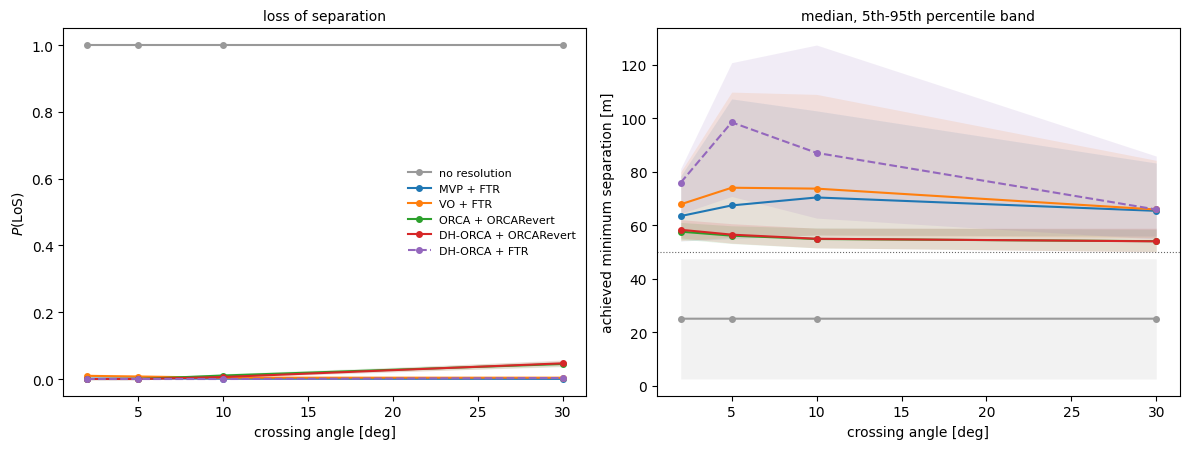

In [5]:
COLOUR = {
    "no resolution": "0.6",
    "MVP + FTR": "tab:blue",
    "VO + FTR": "tab:orange",
    "ORCA + ORCARevert": "tab:green",
    "DH-ORCA + ORCARevert": "tab:red",
    "DH-ORCA + FTR": "tab:purple",
}
STYLE = {"DH-ORCA + FTR": "--"}  # the one non-native resolver/recovery pairing

fig, (ax_p, ax_s) = plt.subplots(1, 2, figsize=(12.0, 4.6))

for label, res in results.items():
    rows = res.records()
    colour, style = COLOUR[label], STYLE.get(label, "-")
    ax_p.plot(DPSI, [r["p_los"] for r in rows], style, marker="o", ms=4, color=colour, label=label)
    ax_p.fill_between(DPSI, [r["p_los_lo"] for r in rows], [r["p_los_hi"] for r in rows],
                      color=colour, alpha=0.12, lw=0)

    seps = [np.asarray(res.cell(dpsi=d).min_seps) for d in DPSI]
    ax_s.plot(DPSI, [np.median(s) for s in seps], style, marker="o", ms=4, color=colour,
              label=label)
    ax_s.fill_between(DPSI, [np.percentile(s, 5) for s in seps],
                      [np.percentile(s, 95) for s in seps], color=colour, alpha=0.12, lw=0)

ax_p.set_xlabel("crossing angle [deg]")
ax_p.set_ylabel(r"$P(\mathrm{LoS})$")
ax_p.set_title("loss of separation", fontsize=10)
ax_p.legend(frameon=False, fontsize=8)

ax_s.axhline(RPZ, color="0.4", lw=0.8, ls=":")
ax_s.set_xlabel("crossing angle [deg]")
ax_s.set_ylabel("achieved minimum separation [m]")
ax_s.set_title("median, 5th-95th percentile band", fontsize=10)

fig.tight_layout()
fig.savefig("orca_vs_mvp_vo.png", dpi=150)
plt.show()

## Where the distributions differ

The survivor curves — `P(min sep < d)` against `d` for each stack, pooled over all four crossing
angles. Same 8000 encounters per stack, read as a CDF instead of thresholded at 50 m, which is what
makes the shape of the tail visible rather than just its one-point value.

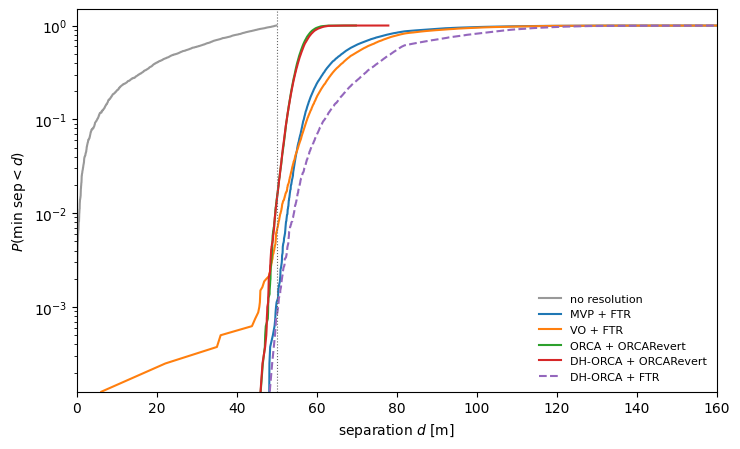

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4.6))

for label, res in results.items():
    pooled = np.sort(np.concatenate([np.asarray(res.cell(dpsi=d).min_seps) for d in DPSI]))
    ax.plot(pooled, np.arange(1, pooled.size + 1) / pooled.size,
            STYLE.get(label, "-"), color=COLOUR[label], label=label)

ax.axvline(RPZ, color="0.4", lw=0.8, ls=":")
ax.set_yscale("log")
ax.set_ylim(1.0 / (len(DPSI) * N_ENCOUNTERS), 1.5)
ax.set_xlim(0.0, 160.0)
ax.set_xlabel("separation $d$ [m]")
ax.set_ylabel(r"$P(\min\ \mathrm{sep} < d)$")
ax.legend(frameon=False, fontsize=8, loc="lower right")
fig.tight_layout()
fig.savefig("orca_vs_mvp_vo_cdf.png", dpi=150)
plt.show()

In [7]:
# the tails, quantified: how often each stack goes below rpz, and how far it goes when it does
print(f"{'stack':21s} {'n_los/8000':>10s} {'deepest':>8s} {'P(<40m)':>9s} {'median':>7s} "
      f"{'95th':>7s}")
for label, res in results.items():
    pooled = np.concatenate([np.asarray(res.cell(dpsi=d).min_seps) for d in DPSI])
    los = pooled[pooled < RPZ]
    print(f"{label:21s} {los.size:10d} {pooled.min():7.1f}m {np.mean(pooled < 40.0):9.5f} "
          f"{np.median(pooled):6.1f}m {np.percentile(pooled, 95):6.1f}m")

stack                 n_los/8000  deepest   P(<40m)  median    95th
no resolution               8000     0.1m   0.79700   25.1m   47.5m
MVP + FTR                      9    48.2m   0.00000   66.4m   95.9m
VO + FTR                      50     6.2m   0.00050   69.4m  100.6m
ORCA + ORCARevert            111    46.0m   0.00000   55.8m   60.1m
DH-ORCA + ORCARevert         106    46.0m   0.00000   56.1m   61.0m
DH-ORCA + FTR                  6    48.3m   0.00000   78.6m  116.5m


# The parallel-track lock, which is what DH-ORCA is actually for

Everything above scores safety and deviation. Neither is the metric DH-ORCA was built to improve —
the paper's headline claim is about the **horizon effect**: ORCA pairs that settle onto parallel
tracks, never cross, and never reach their destinations. `P(LoS)` cannot see that at all. A pair
locked side by side at 51 m is *perfectly safe* and scores as a success.

Our scenario cannot measure "reached its destination" either — the aircraft fly a `CruiseAutopilot`
with no waypoint to arrive at. But the lock itself is directly observable, so this section measures
it with the paper's own criterion (§7.4), simplified to a pair: **tracks within 5° of each other,
same direction, range under `1.5 · rpz`**. The metric is how many seconds an encounter spends in
that state.

These runs are **pinned and noise-free** — one encounter per (stack, angle, miss distance), no GNSS
error — because the lock is a deterministic property of the resolution logic and adding noise would
only blur it. Nine miss distances per cell (`dcpa` 0-40 m, both sides), and `t_max` is raised to
3000 s so that a lock has room to show its full length instead of being cut off.

In [8]:
PARALLEL_DEG = 5.0  # deg: tracks this close count as parallel
PARALLEL_RANGE = 1.5 * RPZ  # m: ... and only while this close together
DCPA_GRID = [(d, s) for d in (0.0, 10.0, 20.0, 40.0) for s in (1, -1)]


def parallel_seconds(resolver, recovery, dpsi: float, dcpa: float, side: int) -> tuple[float, float]:
    """``(seconds spent locked parallel, run duration)`` for one pinned, noise-free encounter."""
    own = AircraftState(id="OWN", lat=52.0, lon=4.0, trk=0.0, gs=BASE.scenario.speed)
    intr = create_conflict(own, intr_id="INT", dpsi=dpsi, dcpa=dcpa,
                           tlos=BASE.scenario.tlos, rpz=RPZ, side=side)
    out = run_fleet(
        [Agent(own, M600), Agent(intr, M600)],
        rpz=RPZ, t_lookahead=TAU, dt=BASE.simulation.dt,
        detector=StateBased(), resolver=resolver, recovery=recovery,
        t_max=3000.0, done_timeout=BASE.simulation.done_timeout, record=True,
    )
    locked = sum(
        BASE.simulation.dt
        for f in out.frames
        if abs((f.states[0].trk - f.states[1].trk + 180.0) % 360.0 - 180.0) < PARALLEL_DEG
        and relative_enu(*f.states).dist < PARALLEL_RANGE
    )
    return locked, out.frames[-1].t


locks = {}
for label, (resolver, recovery) in STACKS.items():
    if resolver is None:
        continue  # nothing to lock: the no-resolution reference never manoeuvres
    locks[label] = {}
    for dpsi in DPSI:
        runs = [parallel_seconds(resolver, recovery, dpsi, d, s) for d, s in DCPA_GRID]
        locks[label][dpsi] = (
            float(np.mean([r[0] for r in runs])),  # mean seconds locked parallel
            max(r[0] for r in runs),               # worst single encounter
            float(np.mean([r[1] for r in runs])),  # mean run duration
        )
    print(f"{label:21s}  " + "  ".join(
        f"{d:.0f}deg: {locks[label][d][0]:6.1f}s (max {locks[label][d][1]:6.1f}s)" for d in DPSI
    ), flush=True)

MVP + FTR              2deg:  207.9s (max  219.0s)  5deg:    0.0s (max    0.0s)  10deg:    0.0s (max    0.0s)  30deg:    0.0s (max    0.0s)


VO + FTR               2deg:  242.4s (max  279.5s)  5deg:    4.5s (max   18.0s)  10deg:    0.0s (max    0.0s)  30deg:    0.0s (max    0.0s)


ORCA + ORCARevert      2deg:  598.8s (max 1564.0s)  5deg:  135.4s (max  279.5s)  10deg:   15.5s (max   62.0s)  30deg:    0.0s (max    0.0s)


DH-ORCA + ORCARevert   2deg:  269.6s (max  340.0s)  5deg:   83.5s (max   96.5s)  10deg:    0.0s (max    0.0s)  30deg:    0.0s (max    0.0s)


DH-ORCA + FTR          2deg:  271.5s (max  339.0s)  5deg:   78.0s (max   87.5s)  10deg:    0.0s (max    0.0s)  30deg:    0.0s (max    0.0s)


In [9]:
print(f"{'stack':21s} {'dpsi':>5s} {'mean locked':>12s} {'worst locked':>13s} "
      f"{'mean run':>9s}")
for label, per_angle in locks.items():
    for dpsi, (mean_lock, worst_lock, mean_run) in per_angle.items():
        print(f"{label:21s} {dpsi:5.0f} {mean_lock:11.1f}s {worst_lock:12.1f}s "
              f"{mean_run:8.1f}s")
    print()

stack                  dpsi  mean locked  worst locked  mean run
MVP + FTR                 2       207.9s        219.0s    221.5s
MVP + FTR                 5         0.0s          0.0s    148.5s
MVP + FTR                10         0.0s          0.0s    124.1s
MVP + FTR                30         0.0s          0.0s    108.1s

VO + FTR                  2       242.4s        279.5s    289.4s
VO + FTR                  5         4.5s         18.0s    164.2s
VO + FTR                 10         0.0s          0.0s    128.9s
VO + FTR                 30         0.0s          0.0s    108.8s

ORCA + ORCARevert         2       598.8s       1564.0s    612.4s
ORCA + ORCARevert         5       135.4s        279.5s    217.4s
ORCA + ORCARevert        10        15.5s         62.0s    145.5s
ORCA + ORCARevert        30         0.0s          0.0s    111.2s

DH-ORCA + ORCARevert      2       269.6s        340.0s    283.2s
DH-ORCA + ORCARevert      5        83.5s         96.5s    164.9s
DH-ORCA + ORCARevert  

Mean seconds locked on parallel tracks, left; the mean run duration it produces, right. A run only
ends once the pair is separated **and diverging** with nobody resolving, so a parallel lock — where
the range is neither opening nor closing — keeps the encounter alive. The run duration is therefore
a second, independent read on the same pathology, and it is the one that would translate into a
missed arrival if these aircraft had destinations.

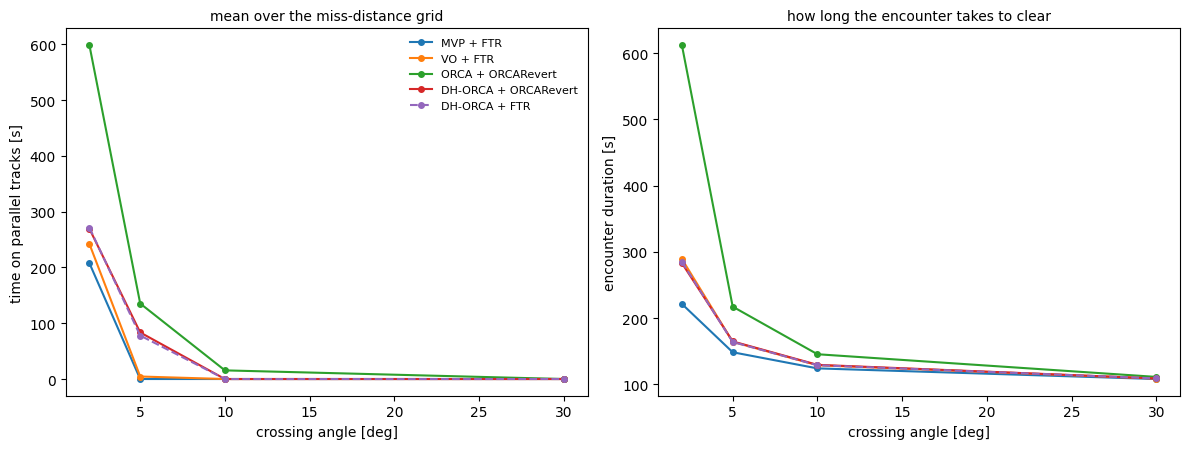

In [10]:
fig, (ax_l, ax_t) = plt.subplots(1, 2, figsize=(12.0, 4.6))

for label, per_angle in locks.items():
    colour, style = COLOUR[label], STYLE.get(label, "-")
    ax_l.plot(DPSI, [per_angle[d][0] for d in DPSI], style, marker="o", ms=4, color=colour,
              label=label)
    ax_t.plot(DPSI, [per_angle[d][2] for d in DPSI], style, marker="o", ms=4, color=colour,
              label=label)

ax_l.set_xlabel("crossing angle [deg]")
ax_l.set_ylabel("time on parallel tracks [s]")
ax_l.set_title("mean over the miss-distance grid", fontsize=10)
ax_l.legend(frameon=False, fontsize=8)

ax_t.set_xlabel("crossing angle [deg]")
ax_t.set_ylabel("encounter duration [s]")
ax_t.set_title("how long the encounter takes to clear", fontsize=10)

fig.tight_layout()
fig.savefig("parallel_track_lock.png", dpi=150)
plt.show()

## ORCA's exposure is a margin, not a property

The safety table leaves both ORCA variants with a higher `P(LoS)` than MVP, and read on its own that
is misleading. The stacks are not aiming at the same thing at `margin = 1.00`:

- MVP's outward gain makes the trajectory *tangent* to the resolution zone, and its avoidance vector
  keeps acting through the whole encounter, so it routinely **overshoots** — median 63-70 m against
  a 50 m zone, 95th percentile near 96 m. That overshoot is a buffer it did not ask for.
- ORCA solves for the **minimum** velocity change that clears `rpz` and no more. Its median is
  54-58 m and its 95th percentile is 60 m. It is doing exactly what it was told, which leaves a 10 m
  GNSS self-fix error nothing to eat into.

So the comparison at `margin = 1.00` measures *what each algorithm targets*, not how safe it can be.
This section gives ORCA the buffer the other two get by accident, sweeping `margin` over 1.00, 1.05,
1.10, 1.20 on the same four angles. `ORCARevert` is left at `rpz` throughout — the margin inflates
the obstacle the resolver clears to, not the radius the recovery tests against, which is the same
convention `MVP`/`FTR` already follow.

In [11]:
MARGINS = [1.00, 1.05, 1.10, 1.20]

orca_margin = run_experiment(
    {
        "dpsi": Sweep(DPSI),
        "resolver": Sweep(
            MARGINS,
            build=lambda m: ORCA(margin=m, t_horizon=TAU, v_max=M600.v_max),
            name="margin",
        ),
    },
    methods=Methods(
        detector=StateBased(),
        recovery=ORCARevert(t_horizon=TAU),
        navigation=GnssNavigation(),
        perf=M600,
    ),
    backend=MC(n_encounters=N_ENCOUNTERS),
    base_config=BASE,
    seed=SEED,
    cache=True,
    n_jobs=-1,
)

print(f"{'dpsi':>5s} {'margin':>7s} {'P(LoS)':>8s} {'95% CI':>20s} {'median':>8s} {'95th':>7s} "
      f"{'worst':>7s}")
for row in orca_margin.records():
    s = np.asarray(orca_margin.cell(dpsi=row["dpsi"], margin=row["margin"]).min_seps)
    print(f"{row['dpsi']:5.0f} {row['margin']:7.2f} {row['p_los']:8.4f} "
          + f"[{row['p_los_lo']:.4f}, {row['p_los_hi']:.4f}]".rjust(21)
          + f" {row['median_min_sep']:7.1f}m {np.percentile(s, 95):6.1f}m {s.min():6.1f}m")

 dpsi  margin   P(LoS)               95% CI   median    95th   worst
    2    1.00   0.0000      [0.0000, 0.0019]    57.6m   61.1m   52.2m
    2    1.05   0.0000      [0.0000, 0.0019]    58.9m   62.2m   53.3m
    2    1.10   0.0000      [0.0000, 0.0019]    60.1m   63.2m   53.7m
    2    1.20   0.0000      [0.0000, 0.0019]    62.8m   65.6m   57.5m
    5    1.00   0.0000      [0.0000, 0.0019]    56.1m   59.8m   50.1m
    5    1.05   0.0000      [0.0000, 0.0019]    57.4m   61.0m   52.0m
    5    1.10   0.0000      [0.0000, 0.0019]    58.7m   62.1m   53.4m
    5    1.20   0.0000      [0.0000, 0.0019]    61.3m   64.8m   55.2m
   10    1.00   0.0105      [0.0069, 0.0160]    54.9m   59.0m   47.1m
   10    1.05   0.0010      [0.0003, 0.0036]    56.2m   60.1m   48.8m
   10    1.10   0.0000      [0.0000, 0.0019]    57.4m   61.3m   50.1m
   10    1.20   0.0000      [0.0000, 0.0019]    59.8m   63.9m   51.8m
   30    1.00   0.0450      [0.0368, 0.0550]    54.1m   58.6m   46.0m
   30    1.05   0.017

ORCA at each margin against the two `FTR` stacks at `margin = 1.00` (dashed and dotted, grey) —
the same reference the first figure used. Left is `P(LoS)`; right is what the extra margin costs in
route deviation, read as the 95th percentile of achieved separation, since a resolver that holds you
100 m off a 50 m zone has taken you somewhere you did not plan to go.

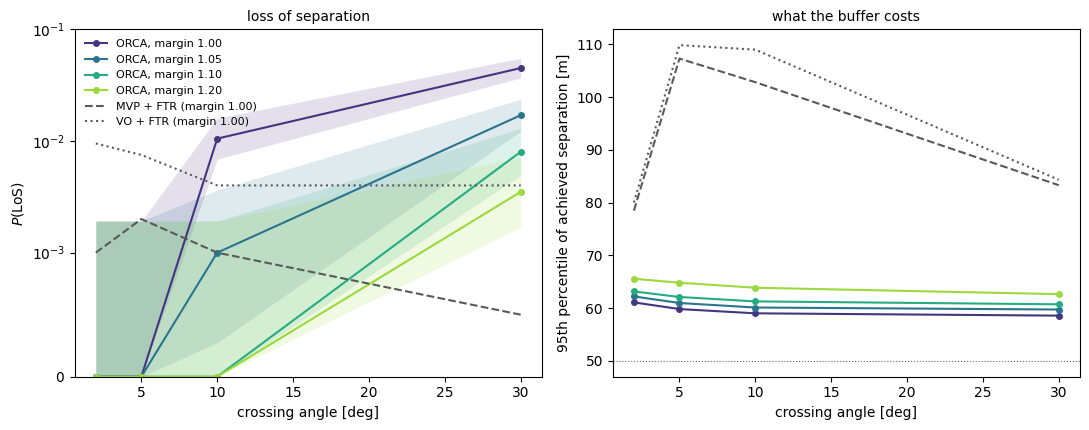

In [12]:
fig, (ax_p, ax_d) = plt.subplots(1, 2, figsize=(11.0, 4.4))
ramp = plt.cm.viridis(np.linspace(0.15, 0.85, len(MARGINS)))

for margin, colour in zip(MARGINS, ramp):
    rows = [r for r in orca_margin.records() if r["margin"] == margin]
    ax_p.plot(DPSI, [r["p_los"] for r in rows], "-o", ms=4, color=colour,
              label=f"ORCA, margin {margin:.2f}")
    ax_p.fill_between(DPSI, [r["p_los_lo"] for r in rows], [r["p_los_hi"] for r in rows],
                      color=colour, alpha=0.15, lw=0)
    p95 = [np.percentile(orca_margin.cell(dpsi=d, margin=margin).min_seps, 95) for d in DPSI]
    ax_d.plot(DPSI, p95, "-o", ms=4, color=colour, label=f"ORCA, margin {margin:.2f}")

for label, style in (("MVP + FTR", "--"), ("VO + FTR", ":")):
    rows = results[label].records()
    ax_p.plot(DPSI, [r["p_los"] for r in rows], style, color="0.35", label=f"{label} (margin 1.00)")
    p95 = [np.percentile(results[label].cell(dpsi=d).min_seps, 95) for d in DPSI]
    ax_d.plot(DPSI, p95, style, color="0.35", label=f"{label} (margin 1.00)")

ax_p.set_yscale("symlog", linthresh=1e-3)
ax_p.set_ylim(0.0, 0.1)
ax_p.set_xlabel("crossing angle [deg]")
ax_p.set_ylabel(r"$P(\mathrm{LoS})$")
ax_p.set_title("loss of separation", fontsize=10)
ax_p.legend(frameon=False, fontsize=8, loc="upper left")

ax_d.axhline(RPZ, color="0.4", lw=0.8, ls=":")
ax_d.set_xlabel("crossing angle [deg]")
ax_d.set_ylabel("95th percentile of achieved separation [m]")
ax_d.set_title("what the buffer costs", fontsize=10)

fig.tight_layout()
fig.savefig("orca_margin_sweep.png", dpi=150)
plt.show()

## What it says

**All five stacks resolve the encounter; none is close to failing.** The do-nothing reference loses
separation in 2000 of 2000 encounters at every angle, median achieved separation 25.1 m — the
geometry is a guaranteed conflict by construction. Against that, every stack below operates in the
1e-4 to 1e-2 range.

Pooled over all four angles (8000 encounters each):

| stack | `P(LoS)` | deepest breach | median sep | 95th pct | lock at 2° (mean) |
| --- | --- | --- | --- | --- | --- |
| no resolution | 1.0000 | 0.1 m | 25.1 m | 47.5 m | — |
| MVP + FTR | 9/8000 = 1.1e-03 | 48.2 m | 66.4 m | 95.9 m | 208 s |
| VO + FTR | 50/8000 = 6.3e-03 | **6.2 m** | 69.4 m | 100.6 m | 242 s |
| ORCA + ORCARevert | 111/8000 = 1.4e-02 | 46.0 m | 55.8 m | 60.1 m | **599 s** |
| DH-ORCA + ORCARevert | 106/8000 = 1.3e-02 | 46.0 m | 56.1 m | 61.0 m | 270 s |
| DH-ORCA + FTR | **6/8000 = 7.5e-04** | 48.3 m | 78.6 m | 116.5 m | 272 s |

### The resolver sets the lock; the recovery sets the safety/deviation trade

That is the cleanest result here, and it falls straight out of comparing stacks 4 and 5, which share
a resolver, against stacks 3 and 4, which share a recovery.

**Stacks 4 vs 5 (same DH-ORCA, different recovery).** The parallel-lock times are
*indistinguishable* — 270 s and 272 s at 2°, 84 s and 78 s at 5°, zero for both above that. Swapping
`ORCARevert(180 s)` for `FTR` does nothing to the horizon effect. But the safety and deviation move
enormously: 106 breaches becomes **6**, and the median separation goes from 56 m to 79 m with the
95th percentile from 61 m to 117 m. `FTR` holds a pair active much longer than `ORCARevert` does
(unbounded horizon, plus the second intruder-reverts criterion), and while the pair is held, DH-ORCA
keeps building separation it was never asked for.

**Stacks 3 vs 4 (same recovery family, resolver differs by the crossing constraint).** Safety and
deviation are within noise of each other — 111 vs 106 breaches, medians 55.8 vs 56.1 m, 95th
percentiles 60.1 vs 61.0 m. The lock times are not: **599 s vs 270 s at 2°**, 135 s vs 84 s at 5°,
16 s vs 0 s at 10°. The mean encounter duration at 2° follows it, 612 s against 283 s.

So DH-ORCA's dual horizon buys a **2.2x reduction in parallel-lock time at essentially zero cost**
on every other metric. That is a clean confirmation of the paper's claim in a completely different
scenario from the one it was tuned on, and `parallel_track_lock.ipynb` shows the mechanism on a
single encounter: ORCA drives both ground tracks to *exactly* 1.00° — perfectly parallel — and holds
them there for a thousand seconds, while DH-ORCA maintains a deliberate 1° split until the crossing
completes.

### The old readings, unchanged

**Counting breaches and measuring them still give different rankings.** ORCA and DH-ORCA breach most
often, but every one of their ~110 breaches is shallow — worst 46.0 m against a 50 m zone, a 4 m
incursion. VO's 50 breaches include four that go deep, the worst reaching **6.2 m**. On `P(LoS)` VO
looks twice as safe as ORCA; on "how bad is it when it goes wrong" they are not comparable. *(The VO
reading is the one to hold loosely — the implementation is ours, and four events is a hypothesis,
not a measurement.)*

**The two ORCA variants are doing exactly what they were asked.** They solve for the minimum
velocity change that clears `rpz` and stop: 95th percentile 60-61 m, the tightest distributions here
by a wide margin, against MVP's 96 m and VO's 101 m. At `margin = 1.00` that leaves a 10 m GNSS
error nothing to eat into, which is where the higher breach count comes from — the absence of a
margin the others were getting for free. The margin sweep closes most of that gap but not all of it:
at 10° `margin = 1.10` takes ORCA to zero breaches, but at 30° MVP stays ahead even at `margin =
1.20` (0.0005 against 0.0035).

**The crossing-angle trend still runs the "wrong" way for the ORCA family.** MVP and VO are roughly
flat across 2°-30°. Both ORCA variants rise from 0.0000 at 2° to ~0.046 at 30° — most exposed at the
*steepest* angle. That follows from the truncated obstacle: at 30° the closing speed is ~5.3 m/s and
the encounter develops inside a 60 s horizon, so they manoeuvre late and precisely once, with no
slack left for navigation error.

### If you had to pick one

For this scenario, **DH-ORCA + FTR** — the safest stack measured (6/8000, no deep tail) and it
carries the dual horizon's lock fix. It pays for that with the largest route deviation of any stack
(95th percentile 117 m), so it is the right answer only where airspace is cheap and separation is
not. Where deviation matters, **DH-ORCA + `ORCARevert` at `margin ≈ 1.10`** is the interesting
untested cell: it should keep the 61 m deviation and the 270 s lock while buying back most of the
breach frequency. That combination is not run here and is the obvious next thing to measure.

### Caveats

`dt = 0.5 s` carries discretisation bias. 2000 encounters puts the Wilson interval on a 1e-03 rate
at roughly [3e-04, 4e-03] — MVP's and DH-ORCA+FTR's per-angle cells are 0-6 events each and must not
be read as curves. **`t_cross = 180 s` is a judgement call, not a tuned value**: the paper selects
its horizons by grid search over the scenario set, nothing here has been tuned that way, and it is
the single largest unquantified choice in the DH-ORCA rows. `t_conflict` is pinned to ORCA's `τ` so
that stacks 3 and 4 differ only by the crossing constraint — a deliberately conservative setup that
probably understates what a tuned DH-ORCA would do. The parallel-lock section is noise-free and
pinned (no GNSS error, one run per miss distance), unlike everything above it. Finally, both
aircraft run the same resolver in every cell, which is what ORCA's reciprocity assumes — a
mixed-equipage encounter would halve the ORCA family's manoeuvre against an intruder that does not
take the other half, and none of these numbers say anything about that.